### PyGrad demo

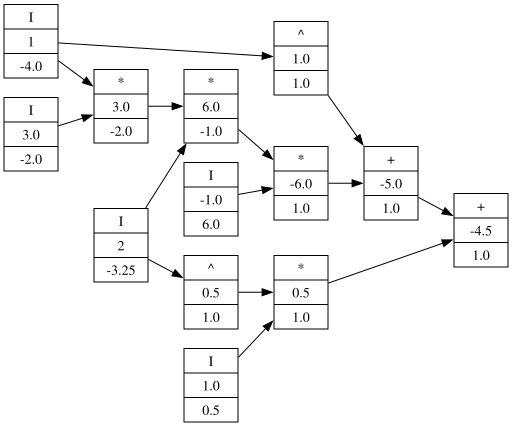

In [1]:
from pygrad.value import Value
from pygrad.utils import draw_graph


def f(x, y):
    return x ** 2 - 3 * x * y + 1 / y


x, y = Value(1), Value(2)
result = f(x, y)
result.backward()
draw_graph(result)

In [2]:
EPS = 1e-6
grad_x = (f(x.data + EPS, y.data) - f(x.data, y.data)) / EPS
grad_y = (f(x.data, y.data + EPS) - f(x.data, y.data)) / EPS
f(x.data, y.data), grad_x, grad_y

(-4.5, -3.9999989986938544, -3.249999875443166)

In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1024, noise=0.1)
y = [2 * yi - 1 for yi in y]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

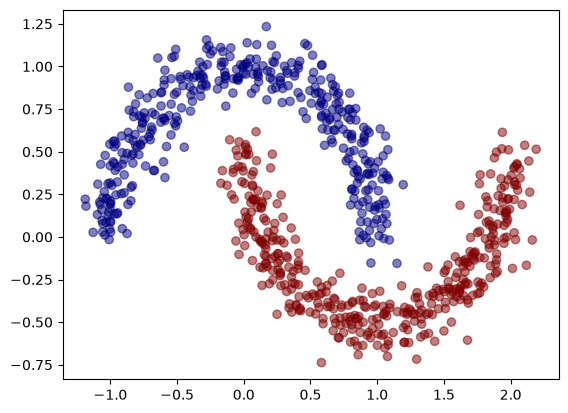

In [4]:
import matplotlib.pyplot as plt 

plt.scatter(X_train[:, 0], X_train[:, 1], alpha=0.5, c=y_train, cmap='jet')

In [ ]:
from pygrad.nn import MLP
from pygrad.train import TrainArgs, DataLoader, max_margin_loss, train


args = TrainArgs(n_epochs=100, min_lr=1e-4, max_lr=1e-2)
model = MLP(2, 8, 16, 8, 1)
data_loader = DataLoader(X_train, y_train)
train(args, model, data_loader, max_margin_loss)

Epoch 1 / 100: loss = 0.9990406871610835
Epoch 2 / 100: loss = 0.9968463645081869
Epoch 3 / 100: loss = 0.9944092968912329
Epoch 4 / 100: loss = 0.9917570380850852
Epoch 5 / 100: loss = 0.9885632190201591
Epoch 6 / 100: loss = 0.9847601014924617
Epoch 7 / 100: loss = 0.9802677880548477
Epoch 8 / 100: loss = 0.9743722257600571
Epoch 9 / 100: loss = 0.966981670833783
Epoch 10 / 100: loss = 0.9568925750950029
Epoch 11 / 100: loss = 0.9425638609043278
Epoch 12 / 100: loss = 0.9201598514956969
Epoch 13 / 100: loss = 0.8838738011852354
Epoch 14 / 100: loss = 0.8179050865448825
Epoch 15 / 100: loss = 0.693707458689885
Epoch 16 / 100: loss = 0.5883190591714226
Epoch 17 / 100: loss = 0.5229048304869565
Epoch 18 / 100: loss = 0.46462500294659304
Epoch 19 / 100: loss = 0.40598930038823905
Epoch 20 / 100: loss = 0.3494921782431915
Epoch 21 / 100: loss = 0.2931351133984051
Epoch 22 / 100: loss = 0.25740956711559987
Epoch 23 / 100: loss = 0.2504498912541891
Epoch 24 / 100: loss = 0.24593026871640725

In [6]:
def calc_accuracy(model, X, target):
    make_pred = lambda x: 1 if model(x)[0].data > 0 else -1
    pred = map(make_pred, X)
    return sum(p == y for p, y in zip(pred, target)) / len(X)

calc_accuracy(model, X_test, y_test)

np.float64(0.90625)